# PS-S06E06: NN - Tabular ResNet (Pseudo-Labeled)

This notebook tackles the [**Playground Series - Season 6, Episode 7: Predicting Student Health Risk**](https://www.kaggle.com/competitions/playground-series-s6e7), a competition focused on predicting a class label (`at-risk`, `unhealthy`, and `fit`) for the `health_condition` target, based on features describing sleep, heart rate, BMI, physical activity, and other lifestyle behaviors for each student.

**Task**
* Three-class classification: predict **at-risk**, **unhealthy**, or **fit**
* Target column: `health_condition`
* Evaluation metric: **Balanced Accuracy**
* Submission format: hard class label per row

**Model**
* Tabular neural network with:
    * Numeric features (BMI, sleep duration, step count, active hours, stress levels, etc.)
    * Embedded categorical features (`stress_level`, `sleep_quality`, `smoking_alcohol`, `gender`, `physical_activity_level`)
    * Residual MLP backbone
* Trained using stratified cross-validation
* Final predictions are averaged (soft) across folds then decoded to class labels

This notebook is one of a number of notebooks that explore various models to address this challenge. The EDA was performed in: [**PS-S06E07: EDA**](https://www.kaggle.com/code/stephentarter/ps-s06e07-eda).

## Import Needed Packages

In [1]:
import os
import gc
import sys
import copy
import math
import random
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import balanced_accuracy_score
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e07_feature_engineering import FeatureFactory
from ps_s06e07_model_visualizer import ModelVisualizer
from ps_s06e07_experiment_setup import ExperimentSetup

warnings.filterwarnings('ignore')

import ipywidgets as widgets
widgets.IntProgress()

IntProgress(value=0)

In [2]:
setup = ExperimentSetup(
    model_name='NN Tabular ResNet Pseudo',
    use_gpu=True,
)

seed = setup.set_seeds()

torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    
setup.configure_pandas()
setup.suppress_warnings()

# The target feature
TARGET = 'health_condition'

# Class label mapping - must be consistent everywhere
target_mapping = {'at-risk': 0, 'unhealthy': 1, 'fit': 2}
inverse_target_mapping = {v: k for k, v in target_mapping.items()}
N_CLASSES = 3

setup.describe()

Random seed set to: 10301
Warnings suppressed.

Experiment Setup
Model         : NN Tabular ResNet Pseudo
Target        : health_condition
Use GPU       : True
RFE           : False
Optuna Tuning : False 
On Kaggle     : False


## Read and Examine the Training Dataset

### Dataset Description
The dataset contains student lifestyle survey responses and behavior indicators.

**Key characteristics**
* Mixed numeric (BMI, step counts, sleep duration, heart rate, active hours, calorie expenditure) and categorical (`stress_level`, `sleep_quality`, `physical_activity_level`, `smoking_alcohol`, `gender`) inputs
* Large dataset (~690k training rows) - well-suited for neural network training
* Target labels are strings: `at-risk`, `unhealthy`, `fit`

**Target encoding**
* `at-risk` &rarr; 0
* `unhealthy` &rarr; 1
* `fit` &rarr; 2

In [3]:
training_df = setup.read_dataset('pseudo')
training_df['is_original'] = False
training_df['is_original'] = training_df['is_original'].astype('bool')
train_ids = training_df['id'].copy()

PSEUDO DATASET

   id health_condition  sleep_duration  heart_rate    bmi  \
0   0        unhealthy           5.220      70.600 25.660   
1   1          at-risk           5.530      71.300 25.840   
2   2        unhealthy           5.290      75.400 24.540   
3   3        unhealthy           4.700      77.200 23.130   
4   4          at-risk           7.230      73.400 28.440   

   calorie_expenditure  step_count  exercise_duration  water_intake diet_type  \
0            2,174.000   1,326.000             19.800         1.860       veg   
1            1,966.000   9,891.000             49.900         1.260   non-veg   
2            2,688.000  14,216.000             38.100         1.600       veg   
3            2,630.000   7,174.000             59.900         2.020       veg   
4            2,560.000   6,584.000             46.000         2.250       veg   

  stress_level sleep_quality physical_activity_level smoking_alcohol  gender  \
0         high       average               sedenta

## Read and Examine the Test Dataset

In [4]:
test_df = setup.read_dataset('test')
test_ids  = test_df['id'].copy()

TEST DATASET

       id  sleep_duration  heart_rate    bmi  calorie_expenditure  step_count  \
0  690088           5.350      64.900 23.480            2,745.000  14,167.000   
1  690089             NaN      83.100 22.420            1,773.000   6,801.000   
2  690090           6.680      59.700 24.140            3,040.000  13,250.000   
3  690091           7.130      78.500 26.260            2,494.000   6,331.000   
4  690092           5.490      77.700 23.290            1,828.000  13,894.000   

   exercise_duration  water_intake diet_type stress_level sleep_quality  \
0             59.500         1.860       veg         high          poor   
1             24.500         2.400  balanced         high          poor   
2             48.500         2.760  balanced       medium          poor   
3             56.900         2.340       veg          low          good   
4             39.400         2.450       veg         high       average   

  physical_activity_level smoking_alcohol gender

## Feature Engineering Strategy
Feature engineering is intentionally conservative to preserve signal for the neural network.

### Applied strategies
* **`encoding`** - Casts categorical features (like `stress_level`, `sleep_quality`, `smoking_alcohol`, `gender`) to `category` dtype so the encoder can build embedding tables for them
* **`sleep_stress`** - Sleep duration and quality metrics interacting with stress levels
* **`activity_energy`** - Step counts, exercise duration, and calorie expenditure interaction ratios
* **`bmi_features`** - Body Mass Index indicators and category mappings
* **`risk_score`** - Calculated composite health risk index based on unhealthy behavior combinations
* **`missing_flags`** - Explicit boolean indicator flags for missing values in survey columns

### Not applied
* **`interactions`** & **`numeric_expansion`** - Higher-order cross-products and math expansions are omitted; the residual network can learn these internally
* **Standard scaling** - Applied inside the training loop per-fold to prevent leakage, not in the FeatureFactory

### Categorical handling
* Categorical features are passed as integer codes to embedding layers. Embeddings are learned directly by the network - no one-hot encoding needed.

In [5]:
fe_strategies = [
    'encoding',
    'sleep_stress',
    'activity_energy',
    'bmi_features',
    'risk_score',
    'missing_flags',
    'numeric_expansion',
]

In [6]:
print('Performing initial feature engineering.')

# Encode target: at-risk=0, unhealthy=1, fit=2
y = training_df[TARGET].map(target_mapping).astype(np.int64).values

feature_engineer = FeatureFactory(
    strategies=fe_strategies,
    target=TARGET,
    seed=seed
)

X_full = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

X = X_full.drop(TARGET, axis=1, errors='ignore')

cat_features = feature_engineer.get_cat_features(X)
print(f'Old Feature Count: {training_df.shape[1] - 1}')
print(f'New Feature Count: {X.shape[1]}')
print(f'Cat features for NN embeddings ({len(cat_features)}): {cat_features}')
print(X.head())

Performing initial feature engineering.
Old Feature Count: 15
New Feature Count: 59
Cat features for NN embeddings (7): ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender', 'bmi_category']
   sleep_duration  heart_rate    bmi  calorie_expenditure  step_count  \
0           5.220      70.600 25.660            2,174.000   1,326.000   
1           5.530      71.300 25.840            1,966.000   9,891.000   
2           5.290      75.400 24.540            2,688.000  14,216.000   
3           4.700      77.200 23.130            2,630.000   7,174.000   
4           7.230      73.400 28.440            2,560.000   6,584.000   

   exercise_duration  water_intake diet_type stress_level sleep_quality  \
0             19.800         1.860       veg         high       average   
1             49.900         1.260   non-veg          low       average   
2             38.100         1.600       veg         high          poor   
3             59.900  

### Model Training: Neural Network Strategy (3-Class Classification)

Model training is performed using **5-Fold Stratified Cross-Validation**.

1. **Feature Scaling and Input Preparation**
   * Numeric features are standardized per-fold to prevent leakage.
   * Categorical features (like `stress_level`, `sleep_quality`, `smoking_alcohol`, `gender`) are integer-encoded and passed to embedding layers.
   * Target is encoded as at-risk=0, unhealthy=1, fit=2.

2. **Stratified Cross-Validation**
   * `StratifiedKFold` preserves class proportions across all three health classes in every fold.
   * Out-of-fold **probability matrices** (N&times;3) are stored for unbiased evaluation and blending.

3. **Optimization Objective**
   * The model is trained using **CrossEntropyLoss** (the standard multi-class objective).
   * The network outputs raw logits of shape `(batch, 3)`; softmax is applied during evaluation.
   * Model performance is evaluated using **Balanced Accuracy**, matching the competition metric.

4. **Adaptive Learning and Early Stopping**
   * **CosineAnnealingWarmRestarts** provides a cyclic LR schedule.
   * **Early stopping** is applied based on validation Balanced Accuracy.
   * Best model weights per fold are restored before inference.

In [7]:
def fit_nn_encoders(X_train: pd.DataFrame, X_ref: pd.DataFrame, cat_cols: list):
    """
    Fit categorical mappings using X_train + X_ref (usually X_test) so test categories are known.
    Return mappings and numeric column list.
    """
    X_all = pd.concat([X_train[cat_cols], X_ref[cat_cols]], axis=0, ignore_index=True)

    cat_maps = {}
    cat_dims = []
    for c in cat_cols:
        s = X_all[c].astype(str).fillna("__nan__")
        uniq = pd.Index(s.unique())
        cat_maps[c] = {k: i for i, k in enumerate(uniq)}
        cat_dims.append(len(uniq))

    num_cols = [c for c in X_train.columns if c not in cat_cols]
    return {"cat_cols": cat_cols, "num_cols": num_cols, "cat_maps": cat_maps, "cat_dims": cat_dims}


def transform_with_encoders(X: pd.DataFrame, fitted):
    cat_cols = fitted["cat_cols"]
    num_cols = fitted["num_cols"]
    cat_maps = fitted["cat_maps"]

    X_num = X[num_cols].to_numpy(dtype=np.float32)

    X_cat = np.zeros((len(X), len(cat_cols)), dtype=np.int64)
    for j, c in enumerate(cat_cols):
        m = cat_maps[c]
        s = X[c].astype(str).fillna("__nan__")
        X_cat[:, j] = s.map(lambda v: m.get(v, 0)).to_numpy(dtype=np.int64)

    return X_num, X_cat

In [8]:
class ResNetBlock(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate):
        super(ResNetBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, input_dim),
            nn.BatchNorm1d(input_dim)
        )
        self.activation = nn.GELU()

    def forward(self, x):
        return self.activation(x + self.block(x))


class TabularResNet(nn.Module):
    def __init__(self, num_dim, cat_dims, n_classes=3, hidden_dim=256, dropout_rate=0.2, num_blocks=4):
        super(TabularResNet, self).__init__()

        # Embedding layers for categoricals
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_cats, emb_dim)
            for num_cats, emb_dim in cat_dims
        ])

        total_cat_dim = sum(emb_dim for _, emb_dim in cat_dims)
        combined_dim = num_dim + total_cat_dim

        self.input_layer = nn.Linear(combined_dim, hidden_dim)
        self.bn0 = nn.BatchNorm1d(hidden_dim)

        self.blocks = nn.ModuleList([
            ResNetBlock(hidden_dim, hidden_dim, dropout_rate)
            for _ in range(num_blocks)
        ])

        # Output head: n_classes logits (was 1 for binary)
        self.output_head = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Linear(128, n_classes)   # 3 outputs for at-risk / unhealthy / fit
        )

    def forward(self, x_num, x_cat):
        embedded_cats = [
            emb_layer(x_cat[:, i])
            for i, emb_layer in enumerate(self.embeddings)
        ]
        x = torch.cat(embedded_cats + [x_num], dim=1)
        x = self.input_layer(x)
        x = self.bn0(x)
        for block in self.blocks:
            x = block(x)
        return self.output_head(x)   # raw logits, shape (batch, 3)

In [9]:
class TabularDataset(torch.utils.data.Dataset):
    """Handles dual numeric + categorical inputs for multi-class targets."""
    def __init__(self, x_num, x_cat, y=None):
        self.x_num = torch.FloatTensor(x_num)
        self.x_cat = torch.LongTensor(x_cat)
        # y is class index (int64) for CrossEntropyLoss
        self.y = torch.LongTensor(y) if y is not None else None

    def __len__(self):
        return len(self.x_num)

    def __getitem__(self, idx):
        if self.y is not None:
            return self.x_num[idx], self.x_cat[idx], self.y[idx]
        return self.x_num[idx], self.x_cat[idx]

### Evaluation Metric
**Primary metric: Balanced Accuracy**
* Computed as the arithmetic mean of per-class recall across at-risk, unhealthy, and fit
* Uses **predicted class labels** (argmax of softmax probabilities)
* Matches the Kaggle leaderboard scoring for this competition

**Why Balanced Accuracy**
* Accounts for class imbalance - fit rows outnumber at-risk and unhealthy cases
* Penalises models that ignore minority classes
* A model that always predicts fit would score only ~0.33

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Training on: {device}')

# Hyperparameters
BATCH_SIZE = 4096
EPOCHS = 200
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

n_folds = 5

# Retrieve seeds from setup
seeds = setup.seed()
if setup.running_in_kaggle():
    print("Running in Kaggle: reducing loop to 1 seed to prevent GPU quota exhaustion.")
    seeds = seeds[:1]

oof_probs_all  = np.zeros((len(training_df), N_CLASSES), dtype=np.float32)
test_probs_all = np.zeros((len(test_df), N_CLASSES), dtype=np.float32)

comp_mask = training_df['is_original'] == False
comp_idx  = np.where(comp_mask)[0]

print(f'Starting Training with {n_folds} folds across {len(seeds)} seed(s)...')

for s_idx, current_seed in enumerate(seeds, 1):
    print(f'\n' + '='*60)
    print(f'SEED RUN {s_idx}/{len(seeds)}: seed={current_seed}')
    print('='*60)
    setup.set_seeds(current_seed)
    torch.manual_seed(current_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(current_seed)
    
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=current_seed)
    
    # Track metrics for this seed
    oof_probs_seed  = np.zeros((len(training_df), N_CLASSES), dtype=np.float32)
    test_probs_seed = np.zeros((len(test_df), N_CLASSES), dtype=np.float32)
    scores = []
    
    for fold, (rel_train_idx, rel_val_idx) in enumerate(skf.split(comp_idx, y[comp_idx]), 1):
        train_idx = np.concatenate([comp_idx[rel_train_idx], np.where(~comp_mask)[0]])
        val_idx   = comp_idx[rel_val_idx]

        print(f'\n=== Seed {current_seed} - Fold {fold}/{n_folds} ===')

        X_train_df = training_df.iloc[train_idx].copy()
        X_val_df   = training_df.iloc[val_idx].copy()
        y_train    = y[train_idx]
        y_val      = y[val_idx]

        # Fit FE on train fold only - prevents leakage
        fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=current_seed + fold)
        X_tr_full = fe_fold.fit_transform(X_train_df)
        X_va_full = fe_fold.transform(X_val_df)
        X_te_full = fe_fold.transform(test_df)

        X_tr = X_tr_full.drop(columns=[TARGET], errors='ignore')
        X_va = X_va_full.drop(columns=[TARGET], errors='ignore')
        X_te = X_te_full.drop(columns=[TARGET], errors='ignore')

        cat_features = fe_fold.get_cat_features(X_tr)
        fitted = fit_nn_encoders(X_tr, X_te, cat_features)

        Xtr_num_np, Xtr_cat_np = transform_with_encoders(X_tr, fitted)
        Xva_num_np, Xva_cat_np = transform_with_encoders(X_va, fitted)
        Xte_num_np, Xte_cat_np = transform_with_encoders(X_te, fitted)

        imputer = SimpleImputer(strategy='median')
        Xtr_num_np = imputer.fit_transform(Xtr_num_np)
        Xva_num_np = imputer.transform(Xva_num_np)
        Xte_num_np = imputer.transform(Xte_num_np)

        assert not np.isnan(Xtr_num_np).any(), "NaN in train features after imputation"
        assert not np.isinf(Xtr_num_np).any(), "Inf in train features after imputation"

        scaler = StandardScaler()
        Xtr_num_np = scaler.fit_transform(Xtr_num_np)
        Xva_num_np = scaler.transform(Xva_num_np)
        Xte_num_np = scaler.transform(Xte_num_np)

        cat_dims = [(n, min(16, int(np.ceil(np.sqrt(n))))) for n in fitted["cat_dims"]]
        num_dim  = Xtr_num_np.shape[1]

        train_ds = TabularDataset(Xtr_num_np, Xtr_cat_np, y_train)
        val_ds   = TabularDataset(Xva_num_np, Xva_cat_np, y_val)
        
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
        val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

        model = TabularResNet(
            num_dim=num_dim,
            cat_dims=cat_dims,
            n_classes=N_CLASSES,
            hidden_dim=256,
            num_blocks=4,
            dropout_rate=0.3,
        ).to(device)

        optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        
        class_counts = np.bincount(y_train)
        weights = 1.0 / class_counts
        class_weights = torch.tensor(weights / weights.sum(), dtype=torch.float32).to(device)

        criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

        scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=10, T_mult=2, eta_min=1e-6
        )
        
        best_val_bal_acc  = -1.0
        best_model_weights = copy.deepcopy(model.state_dict())
        patience_counter  = 0
        ES_PATIENCE = 30
        prev_lr = LEARNING_RATE

        history = {'train_loss': [], 'val_bal_acc': [], 'lrs': []}

        progress_bar = tqdm(range(EPOCHS), desc=f'Fold {fold}', leave=True)

        for epoch in progress_bar:
            model.train()
            running_loss = 0.0

            for batch_num, batch_cat, batch_y in train_loader:
                batch_num = batch_num.to(device)
                batch_cat = batch_cat.to(device)
                batch_y   = batch_y.to(device)

                optimizer.zero_grad()
                logits = model(batch_num, batch_cat)
                loss = criterion(logits, batch_y)
                loss.backward()
                optimizer.step()

                running_loss += loss.item() * batch_num.size(0)

            epoch_loss = running_loss / len(train_loader.dataset)
            history['train_loss'].append(epoch_loss)
            
            model.eval()
            val_preds = []
            val_targets = []

            with torch.no_grad():
                for batch_num, batch_cat, batch_y in val_loader:
                    batch_num = batch_num.to(device)
                    batch_cat = batch_cat.to(device)
                    logits = model(batch_num, batch_cat)
                    probs = torch.softmax(logits, dim=1)
                    preds = torch.argmax(probs, dim=1)
                    val_preds.extend(preds.cpu().numpy())
                    val_targets.extend(batch_y.numpy())

            val_bal_acc = balanced_accuracy_score(val_targets, val_preds)
            history['val_bal_acc'].append(val_bal_acc)

            current_lr = scheduler.optimizer.param_groups[0]['lr']
            history['lrs'].append(current_lr)
            scheduler.step()

            progress_bar.set_postfix({
                'Loss': f'{epoch_loss:.4f}',
                'ValBalAcc': f'{val_bal_acc:.4f}',
                'LR': f'{current_lr:.6f}'
            })

            # ── Early stopping with scheduler integration ─────────────────────────
            if val_bal_acc > best_val_bal_acc:
                best_val_bal_acc = val_bal_acc
                best_model_weights = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                # Reset patience at the start of a new warm-restart cycle: an LR jump
                # means the scheduler just restarted, so any unimproved-epoch count
                # accumulated during the PREVIOUS cycle's low-LR trough is stale and
                # must not carry forward into this cycle's convergence judgement.
                if current_lr > prev_lr * 2:
                    patience_counter = 0
                
                # Only count patience when learning rate is low (below 20% of initial LR) to avoid warm-restart troughs
                if epoch >= 20 and current_lr < 0.2 * LEARNING_RATE:
                    patience_counter += 1
                    if patience_counter >= ES_PATIENCE:
                        print(f'  Early stopping at epoch {epoch + 1}')
                        break

            prev_lr = current_lr
                
        # ── Fold inference ────────────────────────────────────────────────────
        model.load_state_dict(best_model_weights)
        model.eval()

        with torch.no_grad():
            val_num_t  = torch.tensor(Xva_num_np, dtype=torch.float32).to(device)
            val_cat_t  = torch.tensor(Xva_cat_np, dtype=torch.long).to(device)
            val_logits = model(val_num_t, val_cat_t)
            val_probs  = torch.softmax(val_logits, dim=1).cpu().numpy()
            oof_probs_seed[val_idx] = val_probs

            te_num_t   = torch.tensor(Xte_num_np, dtype=torch.float32).to(device)
            te_cat_t   = torch.tensor(Xte_cat_np, dtype=torch.long).to(device)
            te_logits  = model(te_num_t, te_cat_t)
            te_probs   = torch.softmax(te_logits, dim=1).cpu().numpy()
            test_probs_seed += te_probs / n_folds

        fold_preds = np.argmax(val_probs, axis=1)
        fold_score = balanced_accuracy_score(y_val, fold_preds)
        scores.append(fold_score)
        print(f'  Fold {fold} Best Balanced Accuracy: {fold_score:.5f}')

        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            
    oof_probs_all += oof_probs_seed
    test_probs_all += test_probs_seed
    
    filled_mask_seed = oof_probs_seed.sum(axis=1) > 0
    overall_score_seed = balanced_accuracy_score(y[filled_mask_seed], np.argmax(oof_probs_seed, axis=1)[filled_mask_seed])
    print(f'Seed {current_seed} CV Balanced Accuracy: {overall_score_seed:.5f}')

oof_probs = oof_probs_all / len(seeds)
test_probs = test_probs_all / len(seeds)

filled_mask = oof_probs.sum(axis=1) > 0
oof_preds  = np.argmax(oof_probs, axis=1)
overall_score = balanced_accuracy_score(y[filled_mask], oof_preds[filled_mask])
print(f'\nOverall Multi-Seed CV Balanced Accuracy: {overall_score:.5f}')

Training on: cuda
Starting Training with 5 folds across 5 seed(s)...

SEED RUN 1/5: seed=10301
Random seed set to: 10301

=== Seed 10301 - Fold 1/5 ===


Fold 1:   0%|          | 0/200 [00:00<?, ?it/s]

  Fold 1 Best Balanced Accuracy: 0.95637

=== Seed 10301 - Fold 2/5 ===


Fold 2:   0%|          | 0/200 [00:00<?, ?it/s]

  Fold 2 Best Balanced Accuracy: 0.95541

=== Seed 10301 - Fold 3/5 ===


...

  Fold 3 Best Balanced Accuracy: 0.95563

=== Seed 888 - Fold 4/5 ===


Fold 4:   0%|          | 0/200 [00:00<?, ?it/s]

  Fold 4 Best Balanced Accuracy: 0.95538

=== Seed 888 - Fold 5/5 ===


Fold 5:   0%|          | 0/200 [00:00<?, ?it/s]

  Fold 5 Best Balanced Accuracy: 0.95576
Seed 888 CV Balanced Accuracy: 0.95534

Overall Multi-Seed CV Balanced Accuracy: 0.95552


## Visualizing Model Performance
The following diagnostics are generated using out-of-fold predictions:
* Training heartbeat (loss + Balanced Accuracy per epoch)
* Confusion matrix
* ROC curves (one-vs-rest)
* Distribution mismatch across the three health classes

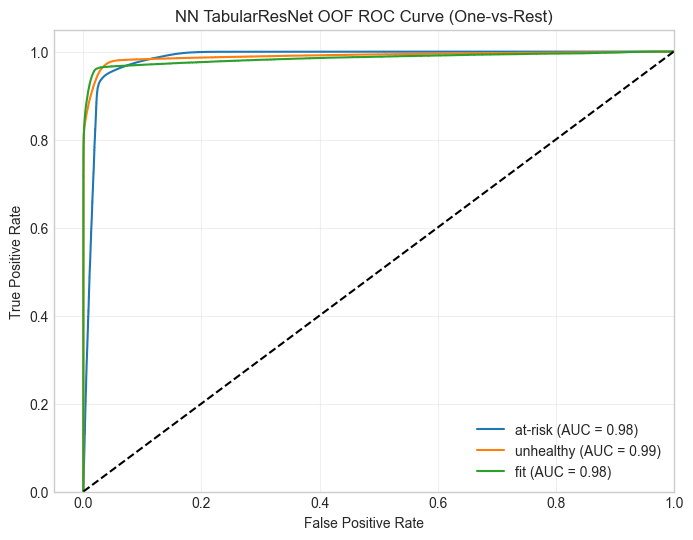

In [11]:
mviz = ModelVisualizer(model_name='NN TabularResNet')

mviz.plot_multiclass_roc_curve(
    y_true=y[filled_mask],
    y_score=oof_probs[filled_mask],
    title='NN TabularResNet OOF ROC Curve (One-vs-Rest)'
)

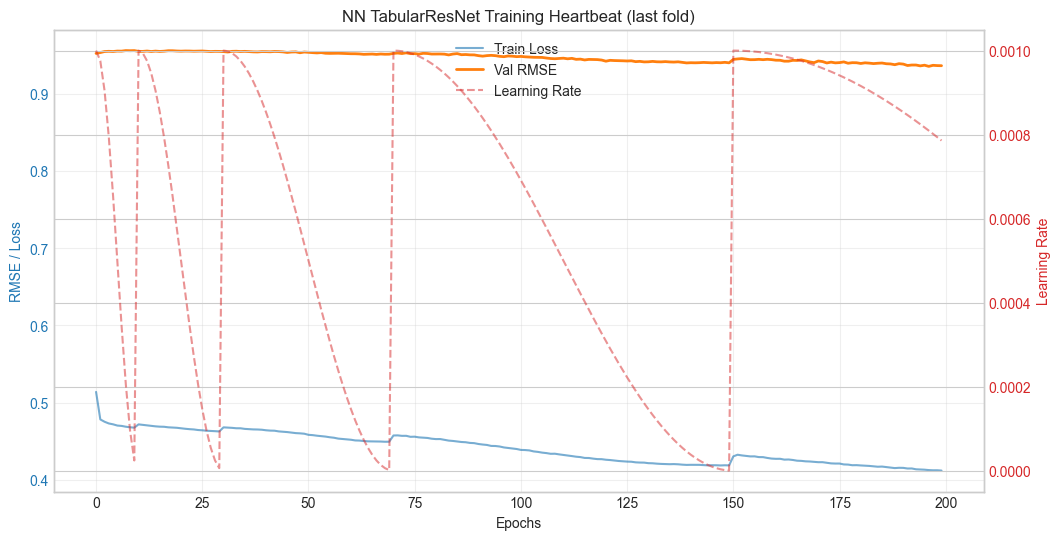

In [12]:
# Rename key to match ModelVisualizer's expected 'val_rmse' slot
# (ModelVisualizer was built for regression; we re-use it with our metric)
heartbeat_history = {
    'train_loss': history['train_loss'],
    'val_rmse':   history['val_bal_acc'],   # display as validation metric
    'lrs':        history['lrs'],
}
mviz.plot_training_heartbeat(heartbeat_history, title_suffix='(last fold)')

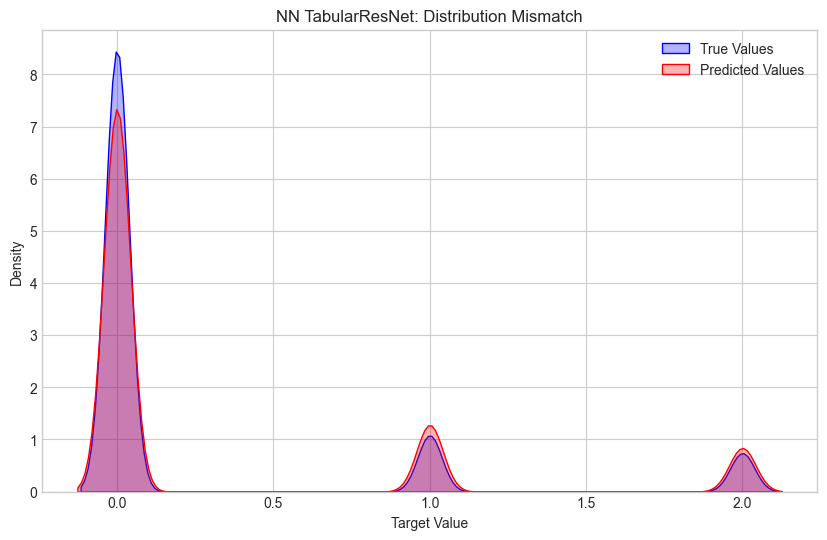

In [13]:
# Distribution of OOF predicted class vs true class (competition rows only)
mviz.plot_distribution_mismatch(y_true=y[filled_mask], y_preds=oof_preds[filled_mask])

Normalized confusion matrix


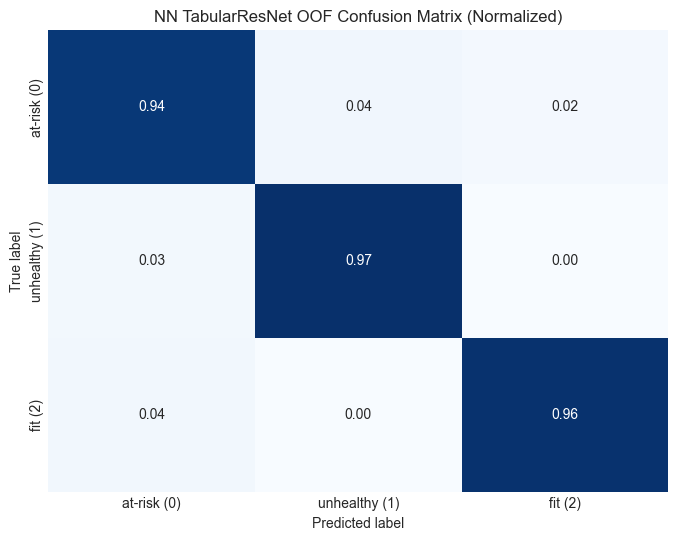

In [14]:
mviz.plot_confusion_matrix(
    y_true=y[filled_mask],
    y_pred=oof_preds[filled_mask],
    classes=['at-risk (0)', 'unhealthy (1)', 'fit (2)'],
    normalize=True,
    title='NN TabularResNet OOF Confusion Matrix (Normalized)'
)

## Prepare Submission

The competition requires a hard predicted class label (`at-risk`, `unhealthy`, or `fit`) for each test row. We derive predictions by taking the argmax of the averaged test probabilities and mapping back to the original string labels.

In [15]:
submission_df = setup.read_dataset('submission')
target_col = [c for c in submission_df.columns if c != 'id'][0]

numeric_preds = np.argmax(test_probs, axis=1)
submission_df[target_col] = pd.Series(numeric_preds).map(inverse_target_mapping)

print('SAMPLE SUBMISSION')
print('=================')
print(submission_df.head(10))

print('\nPredicted Class Distribution:')
print(submission_df[target_col].value_counts(normalize=True).sort_index())

SAMPLE SUBMISSION
       id health_condition
0  690088        unhealthy
1  690089        unhealthy
2  690090          at-risk
3  690091          at-risk
4  690092        unhealthy
5  690093              fit
6  690094          at-risk
7  690095          at-risk
8  690096          at-risk
9  690097          at-risk

Predicted Class Distribution:
health_condition
at-risk     0.811
fit         0.074
unhealthy   0.115
Name: proportion, dtype: float64


In [16]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Probabilities

Out-of-fold (OOF) **probability matrices** (N&times;3) and averaged test-set **probability matrices** are saved for downstream blending and stacking.

These files are used to:
- Compare model performance using OOF Balanced Accuracy
- Analyze correlation and complementarity between models
- Serve as inputs to the blending and stacking notebooks

Each file contains raw, un-thresholded probabilities for all three classes. This is essential for weighted blending, stacking, and calibration analysis.

Column names match the convention used by the other model notebooks:
`prob_at_risk`, `prob_unhealthy`, `prob_fit`

In [18]:
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True)

# Column names match the class label mapping: at-risk=0, unhealthy=1, fit=2
prob_cols = ['prob_at_risk', 'prob_unhealthy', 'prob_fit']

# OOF probabilities — save only competition rows (original rows have no val prediction)
oof_prob_df = pd.DataFrame(oof_probs, columns=prob_cols)
oof_out = pd.concat([
    pd.DataFrame({'id': train_ids.values, 'target': y}),
    oof_prob_df
], axis=1)
oof_out = oof_out[filled_mask]  # drop original rows (no val predictions)
oof_out.to_csv(f'{output_dir}/nn_tabular_resnet_pseudo_oof_probs.csv', index=False)

# Test probabilities
test_prob_df = pd.concat([
    pd.DataFrame({'id': test_ids.values}),
    pd.DataFrame(test_probs, columns=prob_cols)
], axis=1)
test_prob_df.to_csv(f'{output_dir}/nn_tabular_resnet_pseudo_test_probs.csv', index=False)

print(f'Saved for blending/stacking:')
print(f'  {output_dir}/nn_tabular_resnet_pseudo_oof_probs.csv')
print(f'  {output_dir}/nn_tabular_resnet_pseudo_test_probs.csv')

# ── Upload to Kaggle Dataset ──────────────────────────────────────────
if not setup.running_in_kaggle():
    import subprocess
    import shutil
    import json
    import zipfile
    print("\nUploading predictions to Kaggle dataset...")
    staging_dir = 'kaggle_upload'
    existing_dir = 'kaggle_existing'
    temp_preds = 'kaggle_temp_preds'
    os.makedirs(staging_dir, exist_ok=True)
    os.makedirs(existing_dir, exist_ok=True)
    os.makedirs(temp_preds, exist_ok=True)
    try:
        # Download metadata
        metadata_cmd = [
            "/home/tarter/anaconda3/envs/kaggle_env/bin/kaggle",
            "datasets", "metadata",
            "stephentarter/ps-s06e07-nn-tabular-predictions",
            "-p", staging_dir
        ]
        subprocess.run(metadata_cmd, check=True)
        
        # Convert downloaded metadata to the flat format required for uploading
        metadata_path = f'{staging_dir}/dataset-metadata.json'
        with open(metadata_path, 'r') as f:
            meta_raw = json.load(f)
        
        info = meta_raw['info']
        flat_meta = {
            "id": f"{info['ownerUser']}/{info['datasetSlug']}",
            "title": info['title'],
            "licenses": [{"name": "CC0-1.0"}]
        }
        
        with open(metadata_path, 'w') as f:
            json.dump(flat_meta, f, indent=2)
            
        # 2. Download existing files from the dataset to preserve them
        try:
            download_cmd = [
                "/home/tarter/anaconda3/envs/kaggle_env/bin/kaggle",
                "datasets", "download",
                "stephentarter/ps-s06e07-nn-tabular-predictions",
                "-p", existing_dir,
                "--unzip"
            ]
            subprocess.run(download_cmd, check=True)
            
            # Copy existing predictions folder to temp folder
            existing_preds = f'{existing_dir}/predictions'
            if os.path.exists(existing_preds):
                for file in os.listdir(existing_preds):
                    shutil.copy(f'{existing_preds}/{file}', f'{temp_preds}/')
        except Exception as dl_err:
            print(f"Could not download existing files (normal for first upload): {dl_err}")
            
        # 3. Copy newly generated prediction CSVs into the temp folder (overwriting if exist)
        shutil.copy(f'{output_dir}/nn_tabular_resnet_pseudo_oof_probs.csv', f'{temp_preds}/')
        shutil.copy(f'{output_dir}/nn_tabular_resnet_pseudo_test_probs.csv', f'{temp_preds}/')
        
        # 4. Create predictions.zip containing the merged folder structure
        zip_path = f'{staging_dir}/predictions.zip'
        with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
            for file in os.listdir(temp_preds):
                zipf.write(f'{temp_preds}/{file}', f'predictions/{file}')
        
        # 5. Push version
        upload_cmd = [
            "/home/tarter/anaconda3/envs/kaggle_env/bin/kaggle",
            "datasets", "version",
            "-p", staging_dir,
            "-m", "Auto-update pseudo NN predictions from local GPU run"
        ]
        subprocess.run(upload_cmd, check=True)
        print("Kaggle dataset upload completed successfully!")
    except Exception as e:
        print(f"Error uploading to Kaggle: {e}")
    finally:
        for path in (staging_dir, existing_dir, temp_preds):
            if os.path.exists(path):
                shutil.rmtree(path)


Saved for blending/stacking:
  predictions/nn_tabular_resnet_pseudo_oof_probs.csv
  predictions/nn_tabular_resnet_pseudo_test_probs.csv

Uploading predictions to Kaggle dataset...
Downloaded metadata to kaggle_upload/dataset-metadata.json
Starting upload for file predictions.zip


100%|██████████| 15.4M/15.4M [00:01<00:00, 9.98MB/s]


Upload successful: predictions.zip (15MB)
Dataset version is being created. Please check progress at https://www.kaggle.com/datasets/stephentarter/ps-s06e07-nn-tabular-predictions
Kaggle dataset upload completed successfully!
